In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
#

# import libraries 

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jyotikushwaha545/onlineretail")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/jyotikushwaha545/onlineretail


In [12]:
df = pd.read_csv("/kaggle/input/datasets/jyotikushwaha545/onlineretail/OnlineRetail.csv", encoding='ISO-8859-1')

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [14]:
df.shape

(541909, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [16]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(5268)

# Remove missing values

In [19]:
df = df.dropna()

# Remove duplicate rows

In [20]:
df = df.drop_duplicates()

In [21]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [22]:
df = df[df['Quantity'] > 0]

In [23]:
df = df[df['UnitPrice'] > 0]

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature Engineering

In [25]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Descriptive Statistics

In [26]:
avg_purchase = df.groupby('CustomerID')['TotalAmount'].mean()

In [27]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [28]:
customer_lifetime = df.groupby('CustomerID')['TotalAmount'].sum()

In [29]:
summary = pd.DataFrame({
    "Average Purchase": avg_purchase,
    "Purchase Frequency": purchase_frequency,
    "Customer Lifetime Value": customer_lifetime
})

summary.head()

,Average Purchase,Purchase Frequency,Customer Lifetime Value
CustomerID,,,
12346.0,77183.600000,1,77183.60
12347.0,23.681319,7,4310.00
12348.0,57.975484,4,1797.24
12349.0,24.076027,1,1757.55
12350.0,19.670588,1,334.40


# RFM Analysis

In [30]:
today = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [31]:
today

Timestamp('2011-12-10 12:50:00')

In [32]:
recency = df.groupby('CustomerID')['InvoiceDate'].max()

recency = (today - recency).dt.days

In [33]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [39]:
monetary = df.groupby('CustomerID')['TotalAmount'].sum()

In [40]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Feature Selection

In [41]:
X = rfm[['Recency','Frequency','Monetary']]

# Standardization

In [42]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

In [43]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

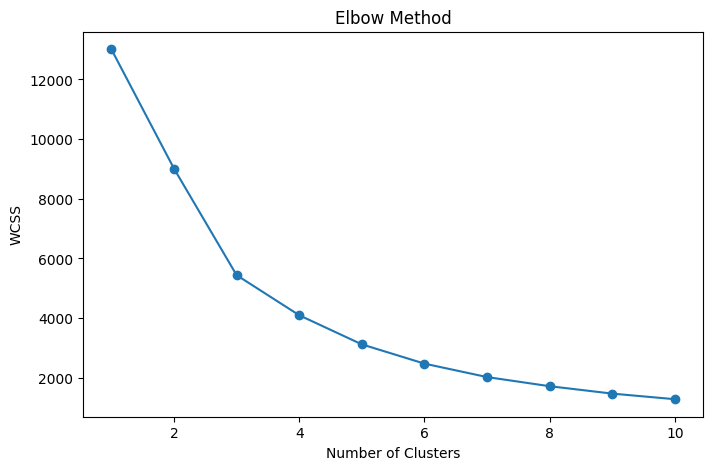

In [44]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Train KMeans

In [45]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

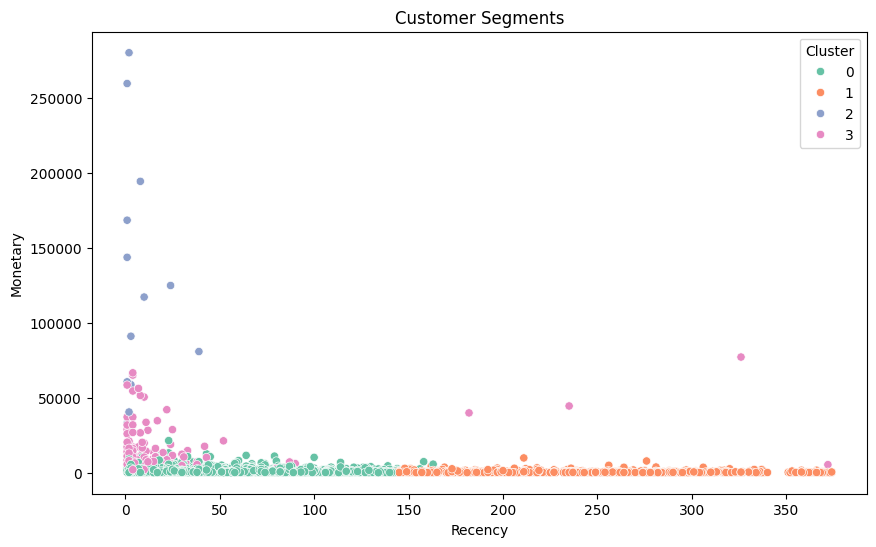

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

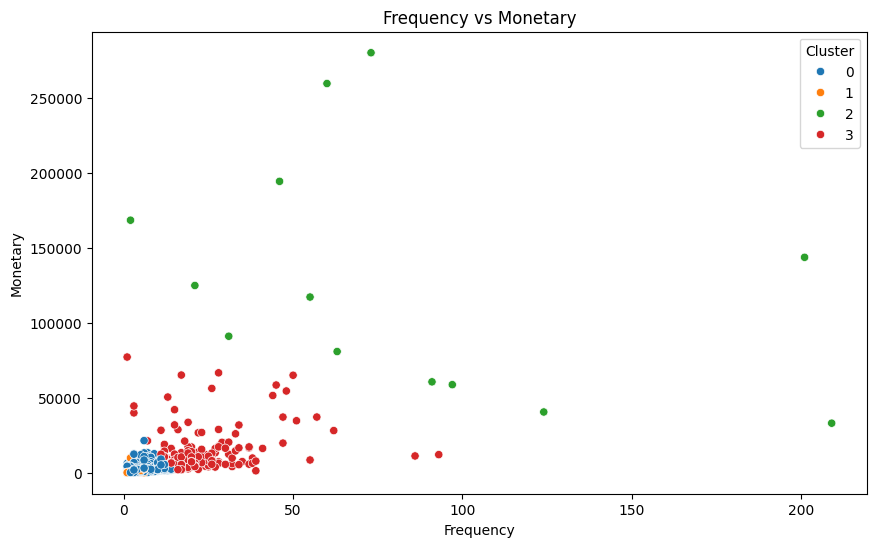

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='tab10'
)

plt.title("Frequency vs Monetary")

plt.show()

In [48]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [49]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [50]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

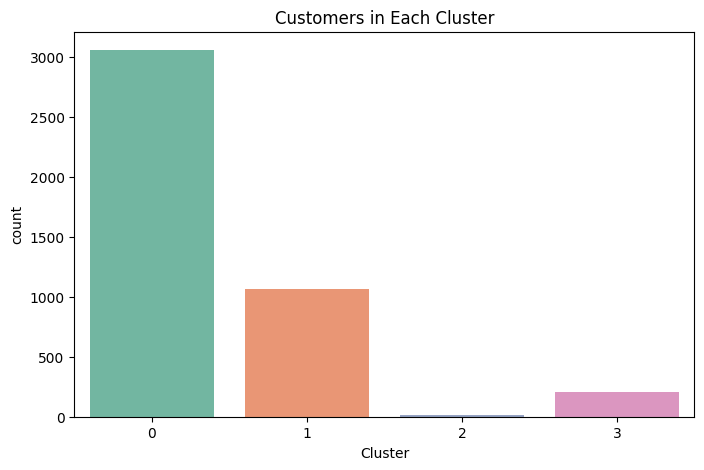

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customers in Each Cluster")

plt.show()

In [52]:
score = silhouette_score(
    X_scaled,
    rfm['Cluster']
)

print(score)

0.6162275299061803


In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.8958
K = 3, Silhouette Score = 0.5942
K = 4, Silhouette Score = 0.6162
K = 5, Silhouette Score = 0.6165
K = 6, Silhouette Score = 0.5983
K = 7, Silhouette Score = 0.5165
K = 8, Silhouette Score = 0.4859
K = 9, Silhouette Score = 0.4784
K = 10, Silhouette Score = 0.4792
